A supervised contrastive approach where family labels are leveraged using supervised contrastive model added to ResNet50 which is trained to keep family pairs close and non-pair family label samples distant in feature space. Trained on 20 epochs and then final embedding extraction is run and samples are clustered hierarchically. 

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
# Import Statements
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math
from PIL import Image
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LambdaLR
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import umap
import shutil
import random
from tqdm import tqdm
import warnings
import glob
import seaborn as sns
import plotly.express as px
from pathlib import Path
from collections import defaultdict
from copkmeans.cop_kmeans import cop_kmeans
from sklearn.metrics import pairwise_distances_argmin_min
from collections import Counter
import multiprocessing
import time
from sklearn.decomposition import PCA

In [3]:
# GPU useage test
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

x = torch.randn(1000, 1000, device=device)
y = torch.mm(x, x)
print(y.device)

Device: cuda
cuda:0


In [4]:
# Paths to image and metadata subset

subset_img_dir = "[YOUR IMG PATH HERE]"    
subset_csv_path = "[YOUR CSV PATH HERE]"        

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load metadata

df_meta = pd.read_csv(subset_csv_path)
assert 'hash_id' in df_meta.columns, "CSV missing 'hash_id' column"
assert 'family' in df_meta.columns, "CSV missing 'family' column"

df_meta.rename(columns={'family': 'family_cluster'}, inplace=True)
print("Metadata preview:")
print(df_meta.head())

# Map images to csv filepaths
image_dir = Path(subset_img_dir)
allowed_exts = {'.jpg', '.jpeg', '.png'}

# 1) Index all images once (recursive, meaning: look into all directories and subdirectories )
all_paths = [p for p in image_dir.rglob("*") if p.suffix.lower() in allowed_exts]
print(f"Indexed {len(all_paths):,} image files")

# 2) Build stem to list(paths) mapping
# Defaultdict(list) creates an empty list for new keys and '.append' adds the object 'p' as a string in that list for every path in our list 'all_paths'
stem_to_paths = defaultdict(list)
for p in all_paths:
    stem_to_paths[p.stem].append(str(p)) # p.stem is filepath without the extension (without jpeg, jpg, or png)

# 3) Create a simple first-match dict (stem to first path)
first_match = {stem: paths[0] for stem, paths in stem_to_paths.items()}

# 4) Vectorized mapping into dataframe (fast)
df_meta['hash_id_str'] = df_meta['hash_id'].astype(str).str.strip()
df_meta['path'] = df_meta['hash_id_str'].map(first_match)  # NaN for missing

# 5) Build the same dict you had originally
df_meta_found = df_meta[df_meta['path'].notna()].reset_index(drop=True)
hashid_to_path = dict(zip(df_meta_found['hash_id_str'], df_meta_found['path']))
missing_hashids = df_meta[df_meta['path'].isna()]['hash_id_str'].tolist()

print(f"Found {len(hashid_to_path):,} matches; {len(missing_hashids):,} missing.")
if missing_hashids:
    print("Example missing ids:", missing_hashids[:5])

Using device: cuda
Metadata preview:
                    hash_id family_cluster
0  223m6ywujk3htx2s3kfqx7ee    Acanthaceae
1  2aba7w224g4tso44mtzpnizg    Acanthaceae
2  2dovrj4uex7apou4zyu7nau7    Acanthaceae
3  2f53p6wsfhsnik2sy3jxn2ok    Acanthaceae
4  2fvqsa7ldatavhuevcvia5lm    Acanthaceae
Indexed 49,633 image files
Found 49,633 matches; 0 missing.


In [5]:
# Define FamilyDataset subclass
class FamilyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = row["family_label"]
        return img, label

In [6]:
# ResNet50 2 layer extraction: layer 3 and global avg pool layer
class DualResNet50(nn.Module):
    def __init__(self, pretrained=True, proj_dim=128):
        super().__init__()
        from torchvision.models import resnet50, ResNet50_Weights

        # Use weights argument for pretrained
        weights = ResNet50_Weights.DEFAULT if pretrained else None
        base_model = resnet50(weights=weights)

        # Store the initial layers up to layer2
        self.initial_layers = nn.Sequential(
            base_model.conv1,
            base_model.bn1,
            base_model.relu,
            base_model.maxpool,
            base_model.layer1,
            base_model.layer2
        )

        # Store layer3 and layer4 separately
        self.layer3 = base_model.layer3
        self.layer4 = base_model.layer4
        self.avgpool = base_model.avgpool

        # Projection heads
        self.proj_genus = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, proj_dim)
        )
        self.proj_species = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Linear(512, proj_dim)
        )

    def forward(self, x):
        # Initial layers
        x = self.initial_layers(x)  # up to layer2

        # Genus embeddings
        genus_feats = self.layer3(x)  # output 1024 channels
        genus_emb = F.adaptive_avg_pool2d(genus_feats, (1,1)).flatten(1)
        genus_emb = F.normalize(self.proj_genus(genus_emb), dim=1)

        # Species embeddings
        species_feats = self.layer4(genus_feats)  # input 1024 channels, output 2048 channels
        species_feats = self.avgpool(species_feats).flatten(1)
        species_emb = F.normalize(self.proj_species(species_feats), dim=1)

        return genus_emb, species_emb

In [7]:
# Supervised Contrastive learning loss calculation
class SupConLoss(nn.Module):
    def __init__(self, temperature=0.12):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        contrast = torch.div(torch.matmul(features, features.T), self.temperature)
        logits_max, _ = torch.max(contrast, dim=1, keepdim=True)
        logits = contrast - logits_max.detach()
        
        exp_logits = torch.exp(logits) * (1 - torch.eye(labels.shape[0], device=device))
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        mean_log_prob_pos = (mask * log_prob).sum(1) / mask.sum(1)
        loss = -mean_log_prob_pos.mean()
        return loss

In [8]:
# Warmup and cosine annealing scheduler to improve contrastive learning performance
def get_cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(current_epoch):
        # Warmup phase
        if current_epoch < warmup_epochs:
            return float(current_epoch) / float(max(1, warmup_epochs))

        # Annealing phase
        progress = float(current_epoch - warmup_epochs) / float(max(1, total_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return LambdaLR(optimizer, lr_lambda)

In [9]:
# Model training using contrastive loss
def train_contrastive_amp(df_meta,
                          epochs=20,
                          lr=4e-4,
                          proj_dim=256):
    # Map families to integers
    families = sorted(df_meta["family_cluster"].unique())
    family_to_idx = {fam: i for i, fam in enumerate(families)}
    df_meta["family_label"] = df_meta["family_cluster"].map(family_to_idx)

    # Transform: smaller crop to reduce memory
    transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.2, 1.0)),
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
        transforms.RandomGrayscale(p=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
    dataset = FamilyDataset(df_meta, transform)
    
    # Batch size reduced for 6GB VRAM
    loader = DataLoader(dataset, batch_size=48, shuffle=True, num_workers=0, pin_memory=True)

    model = DualResNet50(pretrained=True, proj_dim=proj_dim).cuda()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    warmup_epochs=3,
    total_epochs=epochs
)
    criterion = SupConLoss(temperature=0.12)

    scaler = GradScaler(device='cuda') 
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for imgs, labels in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, labels = imgs.cuda(non_blocking=True), labels.cuda(non_blocking=True)

            optimizer.zero_grad()
            with autocast(device_type='cuda'):  # mixed precision forward
                genus_emb, species_emb = model(imgs)
                features = torch.cat([genus_emb, species_emb], dim=0)
                label_batch = torch.cat([labels, labels], dim=0)
                loss = criterion(features, label_batch)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()
        # Warmup and cosine annealing
        scheduler.step()

        # Print loss and learning rate
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}: Loss = {total_loss/len(loader):.4f}, LR = {current_lr:.6f}")

        # Empty tensor cache after each epoch to prevent crashing
        torch.cuda.empty_cache()

    return model, family_to_idx

In [10]:
def extract_embeddings(model, df_meta):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    dataset = FamilyDataset(df_meta, transform)
    loader = DataLoader(dataset, batch_size=48, shuffle=False)

    model.eval()
    genus_embeds, species_embeds = [], []
    with torch.no_grad():
        for imgs, _ in tqdm(loader, desc="Extracting embeddings"):
            imgs = imgs.cuda()
            g_emb, s_emb = model(imgs)
            genus_embeds.append(g_emb.cpu())
            species_embeds.append(s_emb.cpu())
    return torch.cat(genus_embeds).numpy(), torch.cat(species_embeds).numpy()

In [31]:
# Clustering
def hierarchical_cluster_with_metadata(
    genus_embeds,
    species_embeds,
    family_labels,  # array of known families for each sample
    max_genus_per_family=10,
    max_species_per_genus=10,
    random_seed=42
):
    np.random.seed(random_seed)

    n_samples = len(family_labels)
    unique_families = np.unique(family_labels)

    # Initialize arrays for genus and species labels
    genus_labels = np.empty(n_samples, dtype=int)
    species_labels = np.empty(n_samples, dtype=int)

    current_genus_id = 0
    current_species_id = 0

    for fam in unique_families:
        # Select samples belonging to this family
        fam_idx = np.where(family_labels == fam)[0]
        fam_genus_embeds = genus_embeds[fam_idx]

        # Get unique genus embeddings and inverse mapping
        unique_genus_embeds, inverse_idx_genus = np.unique(fam_genus_embeds, axis=0, return_inverse=True)
        k_genus = min(max_genus_per_family, len(unique_genus_embeds))
        if k_genus < 1:
            continue

        # Cluster unique embeddings
        unique_genus_labels = KMeans(n_clusters=k_genus, random_state=random_seed).fit_predict(unique_genus_embeds)

        # Map back to all samples in the family
        genus_sub_labels = unique_genus_labels[inverse_idx_genus]

        for i in range(k_genus):
            idx_i = fam_idx[genus_sub_labels == i]
            genus_labels[idx_i] = current_genus_id

            if len(idx_i) == 0:
                continue

            # Species-level clustering within this genus
            species_embeds_i = species_embeds[idx_i]

            # Handle duplicates in species embeddings
            unique_species_embeds, inverse_idx_species = np.unique(species_embeds_i, axis=0, return_inverse=True)
            k_species = min(max_species_per_genus, len(unique_species_embeds))
            if k_species < 1:
                continue

            unique_species_labels = KMeans(n_clusters=k_species, random_state=random_seed).fit_predict(unique_species_embeds)
            species_sub_labels = unique_species_labels[inverse_idx_species]

            for j in range(k_species):
                idx_j = idx_i[species_sub_labels == j]
                species_labels[idx_j] = current_species_id
                current_species_id += 1

            current_genus_id += 1

    return family_labels, genus_labels, species_labels

In [12]:
# Call contrastive training and feature extractor function
df_meta_found["family_label"] = df_meta_found["family_cluster"].astype("category").cat.codes # precedes train_contrastive call
# Train contrastive supervised learning
model, fam_to_idx = train_contrastive_amp(df_meta_found, epochs=20)
# Extract features using trained contrastive learning model
genus_embeds, species_embeds = extract_embeddings(model, df_meta_found)

Epoch 1/20: 100%|██████████| 1035/1035 [15:24<00:00,  1.12it/s]


Epoch 1/20: Loss = 5.8689, LR = 0.000133


Epoch 2/20: 100%|██████████| 1035/1035 [16:09<00:00,  1.07it/s]


Epoch 2/20: Loss = -0.0498, LR = 0.000267


Epoch 3/20: 100%|██████████| 1035/1035 [16:03<00:00,  1.07it/s]


...

Epoch 19/20: 100%|██████████| 1035/1035 [16:33<00:00,  1.04it/s]


Epoch 19/20: Loss = -0.3972, LR = 0.000003


Epoch 20/20: 100%|██████████| 1035/1035 [16:39<00:00,  1.04it/s]


Epoch 20/20: Loss = -0.3919, LR = 0.000000


Extracting embeddings: 100%|██████████| 1035/1035 [08:44<00:00,  1.97it/s]


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

cos = cosine_similarity(genus_embeds)
np.mean(cos), np.std(cos)

(0.011365465, 0.1102369)

In [34]:
# family_labels come directly from metadata
family_labels_meta = df_meta_found['family_cluster'].values  

family_labels_num, genus_labels, species_labels = hierarchical_cluster_with_metadata(
    genus_embeds=genus_embeds,
    species_embeds=species_embeds,
    family_labels=family_labels_meta,
    max_genus_per_family=15,
    max_species_per_genus=15
)

In [35]:
# How many clusters
print(len(np.unique(family_labels_num)))
print(len(np.unique(genus_labels)))
print(len(np.unique(species_labels)))

179
2685
32795


In [28]:
# Create results dataframe
df_result = pd.DataFrame({
    'hash_id': df_meta_found['hash_id'].values,  # use the hash IDs from the metadata
    'family_cluster': family_labels_num,
    'genus_cluster': genus_labels,
    'species_cluster': species_labels
})

df_result.head(n=7)

,hash_id,family_cluster,genus_cluster,species_cluster
0,223m6ywujk3htx2s3kfqx7ee,Acanthaceae,10,84
1,2aba7w224g4tso44mtzpnizg,Acanthaceae,12,89
2,2dovrj4uex7apou4zyu7nau7,Acanthaceae,10,84
3,2f53p6wsfhsnik2sy3jxn2ok,Acanthaceae,8,71
4,2fvqsa7ldatavhuevcvia5lm,Acanthaceae,3,25
5,2hfnnbd3jynefj7wwrjmoiom,Acanthaceae,1,16
6,2io2zgcmes2cyb7sqsretfaf,Acanthaceae,8,68


In [29]:
df_result.to_csv("[YOUR RESULTS CSV PATH HERE]", index=False)

C:\Users\mlasz\anaconda3\envs\biotrove\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


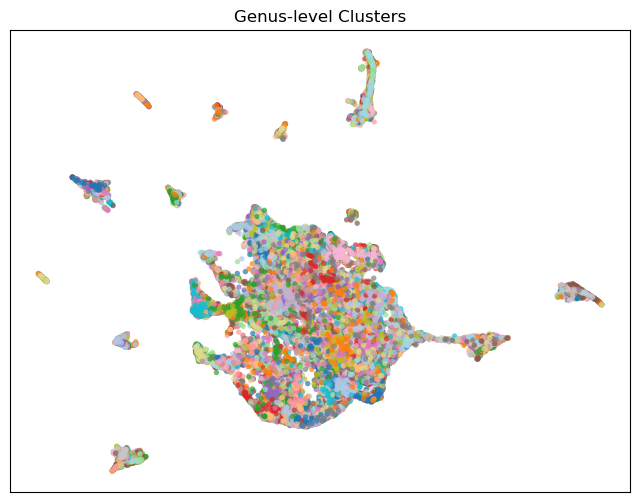

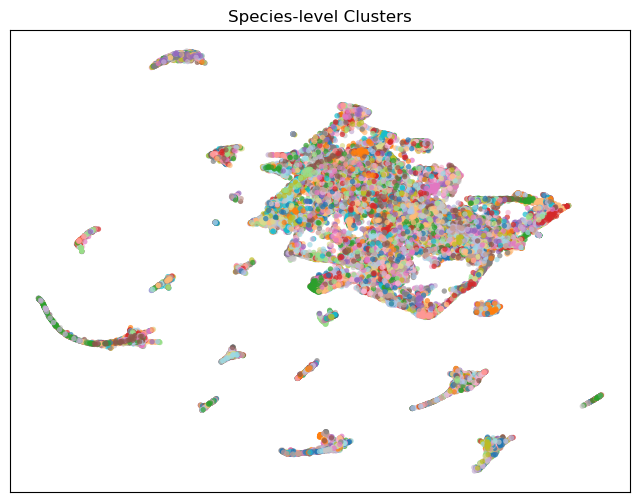

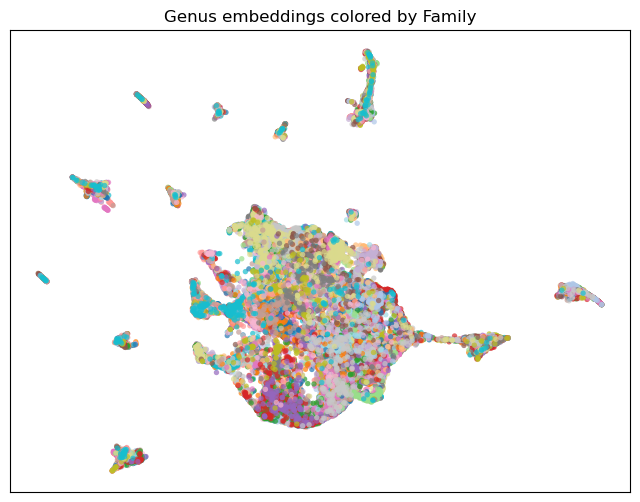

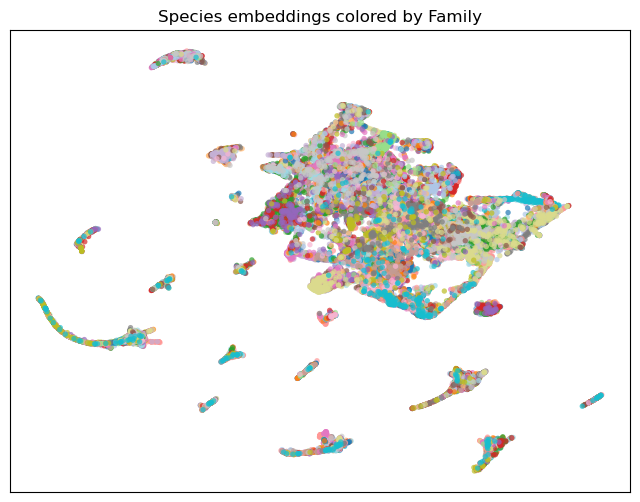

In [22]:
# Reduce to 2D for plotting
umap_2d = umap.UMAP(n_neighbors=15, n_components=2, min_dist=0.1, random_state=seed)
genus_2d = umap_2d.fit_transform(genus_embeds)
species_2d = umap_2d.fit_transform(species_embeds)

# Plot function
def plot_umap(coords, labels, title):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=labels, s=15, linewidth=0, alpha=0.7, palette="tab20")
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.legend([],[], frameon=False)
    plt.show()

# Visualize genus clusters
plot_umap(genus_2d, genus_labels, "Genus-level Clusters")

# Visualize species clusters
plot_umap(species_2d, species_labels, "Species-level Clusters")

# Optionally color by family
plot_umap(genus_2d, df_result['family_cluster'], "Genus embeddings colored by Family")
plot_umap(species_2d, df_result['family_cluster'], "Species embeddings colored by Family")